# Classification NORMAL vs PNEUMONIA (radiographies thoraciques)

**Objectif :** Entraîner un petit CNN pour distinguer des radiographies normales de celles avec pneumonie, puis évaluer le modèle et visualiser les résultats.

**Dataset :** Chest X-Ray Images (Pneumonia) sur Kaggle.  
Structure attendue des dossiers :
- `chest_xray/train/NORMAL/` et `chest_xray/train/PNEUMONIA/`
- `chest_xray/val/` et `chest_xray/test/` avec les mêmes sous-dossiers

Adapte la variable `data_dir` plus bas si tes données sont ailleurs.


### Pour Google Colab

1. **Transférer le notebook** : Fichier → Téléverser le notebook → choisis `chest_xray_cnn.ipynb`.
2. **Données** : soit tu téléverses le dossier `chest_xray` (train/val/test) dans le panneau Fichiers (📁) de Colab, soit tu le mets sur Google Drive et tu exécutes la cellule « Montage Google Drive » ci-dessous, puis tu adaptes `data_dir` vers ton chemin (ex. `Path("/content/drive/MyDrive/chest_xray")`).
3. **GPU** : Exécution → Changer le type d’exécution → Accélérateur matériel : GPU (T4).
4. Exécute les cellules dans l’ordre. Sur Colab, `num_workers` est déjà réglé à 0 pour éviter les erreurs.

## 1. Imports et configuration

On importe les librairies nécessaires (torch, torchvision, numpy, matplotlib).  
Le device (cuda / mps / cpu) est choisi automatiquement.


---
## Installation des dépendances

**Exécute la cellule ci-dessous une seule fois** (au premier lancement du notebook).  
Ensuite, redémarre le noyau (Kernel → Restart) puis exécute toutes les cellules depuis le début.

In [1]:
# Installation des dépendances (à exécuter une seule fois)
import sys

# On installe uniquement les dépendances "non-torch" ici.
# PyTorch est géré séparément avec des wheels CPU stables.
!{sys.executable} -m pip install -q numpy matplotlib pillow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Détection Google Colab (à exécuter une fois)
try:
    import google.colab
    IN_COLAB = True
    # Si tes données sont sur Google Drive, décommente les 2 lignes suivantes :
    # from google.colab import drive
    # drive.mount("/content/drive")
except ImportError:
    IN_COLAB = False
print("Colab:", IN_COLAB)

Colab: False


In [3]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Choix du device (GPU / MPS / CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Mac (Apple Silicon)
else:
    device = torch.device("cpu")

print(f"Device utilisé : {device}")


Device utilisé : cpu


In [4]:
## 2. Chargement et inspection des données

data_dir = Path(r"C:\Users\LADY_M\Projet_Deep_Learning\data\chest_xray")
train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

print("Train dir exists:", train_dir.exists())
print("Val dir exists:", val_dir.exists())
print("Test dir exists:", test_dir.exists())

def count_images(root):
    counts = {}
    for split in ["train", "val", "test"]:
        split_dir = root / split
        split_counts = {}
        if not split_dir.exists():
            counts[split] = split_counts
            continue
        for cls in sorted(os.listdir(split_dir)):
            cls_dir = split_dir / cls
            if not cls_dir.is_dir():
                continue
            n = len([f for f in cls_dir.iterdir() if f.is_file()])
            split_counts[cls] = n
        counts[split] = split_counts
    return counts

counts = count_images(data_dir)
counts


Train dir exists: True
Val dir exists: True
Test dir exists: True


{'train': {'NORMAL': 1341, 'PNEUMONIA': 3875},
 'val': {'NORMAL': 8, 'PNEUMONIA': 8},
 'test': {'NORMAL': 234, 'PNEUMONIA': 390}}

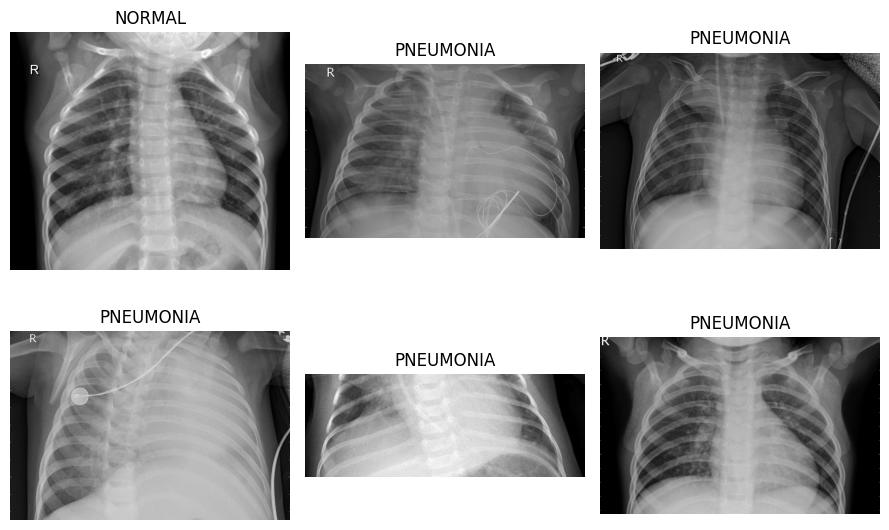

In [5]:
from PIL import Image
import random

def show_random_images(split_dir, n=6):
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * (n // 2), 6))
    axes = axes.flatten()
    classes = ["NORMAL", "PNEUMONIA"]
    images = []
    for cls in classes:
        cls_dir = split_dir / cls
        if not cls_dir.exists():
            continue
        files = [f for f in cls_dir.iterdir() if f.is_file()]
        images.extend([(f, cls) for f in files])
    random.shuffle(images)
    images = images[:n]
    for ax, (path, cls) in zip(axes, images):
        img = Image.open(path).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(cls)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

if train_dir.exists():
    show_random_images(train_dir)


## 3. Prétraitement & data augmentation

- Redimensionnement à 224×224.
- Conversion en tenseur et normalisation (statistiques ImageNet, adaptées aux modèles pré-entraînés si besoin).
- Augmentations légères appliquées uniquement au train (rotations, translations, léger zoom).


In [6]:
input_size = 224

# Transformations simples :
# - redimensionnement
# - conversion en tenseur (valeurs entre 0 et 1)
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
])


## 4. Construction des `Dataset` et `DataLoader`


In [7]:
batch_size = 32

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

class_names = train_dataset.classes
print("Classes:", class_names)

# Sur Colab, num_workers=0 évite les erreurs de workers
nw = 0 if (globals().get("IN_COLAB", False)) else 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=nw)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=nw)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=nw)


Classes: ['NORMAL', 'PNEUMONIA']


## 5. Architecture CNN baseline


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 -> 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (input_size // 8) * (input_size // 8), 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x  # logits

model = SimpleCNN().to(device)
model


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

## 6. Fonction de coût, optimisation et boucle d’entraînement


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 25
patience = 5  # early stopping

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().ravel().tolist())
            all_probs.extend(probs.cpu().numpy().ravel().tolist())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_probs)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_loss = float("inf")
best_state_dict = None
epochs_no_improve = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} - Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping déclenché.")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)


Epoch 1/25 - Train loss: 0.3097, acc: 0.8679 - Val loss: 0.4691, acc: 0.8750
Epoch 2/25 - Train loss: 0.1856, acc: 0.9342 - Val loss: 0.4930, acc: 0.7500
Epoch 3/25 - Train loss: 0.1537, acc: 0.9448 - Val loss: 0.4864, acc: 0.7500
Epoch 4/25 - Train loss: 0.1416, acc: 0.9500 - Val loss: 0.6180, acc: 0.6875
Epoch 5/25 - Train loss: 0.1186, acc: 0.9557 - Val loss: 0.5143, acc: 0.6875


## 7. Courbes d’apprentissage (loss & accuracy)


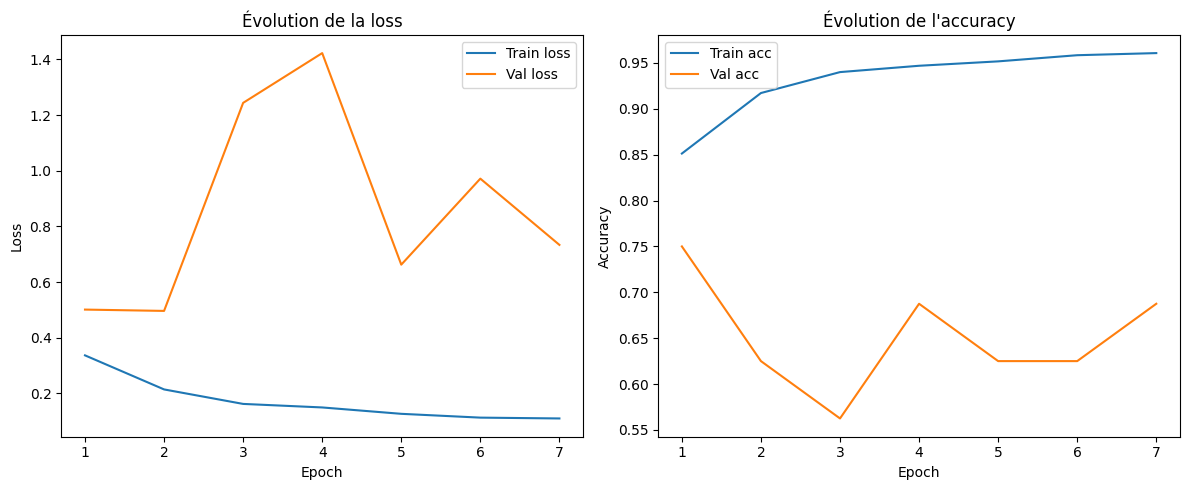

In [24]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train loss")
plt.plot(epochs_range, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Évolution de la loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train acc")
plt.plot(epochs_range, history["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Évolution de l'accuracy")

plt.tight_layout()
plt.show()


## 8. Évaluation sur le test set

- Matrice de confusion.
- Accuracy, Precision, Recall, F1-score.
- AUC ROC et courbe ROC (et PR si besoin).


In [25]:
# Évaluation simple avec métriques de base (sans scikit-learn)

test_loss, test_acc, y_true, y_prob = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

# Seuil de décision à 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Matrice de confusion :
# [[TN, FP],
#  [FN, TP]]
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))
TP = np.sum((y_true == 1) & (y_pred == 1))

cm = np.array([[TN, FP], [FN, TP]])
print("Matrice de confusion:\n", cm)

# Métriques classiques
accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-8)
precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)  # sensibilité
specificity = TN / (TN + FP + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Specificité : {specificity:.4f}")
print(f"F1-score : {f1:.4f}")


python(31459) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(31460) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Test loss: 0.9070, Test accuracy: 0.7244
Matrice de confusion:
 [[ 63 171]
 [  1 389]]
Accuracy  : 0.7244
Precision : 0.6946
Recall    : 0.9974
Specificité : 0.2692
F1-score : 0.8189


## 9. Visualisation de la matrice de confusion et des erreurs


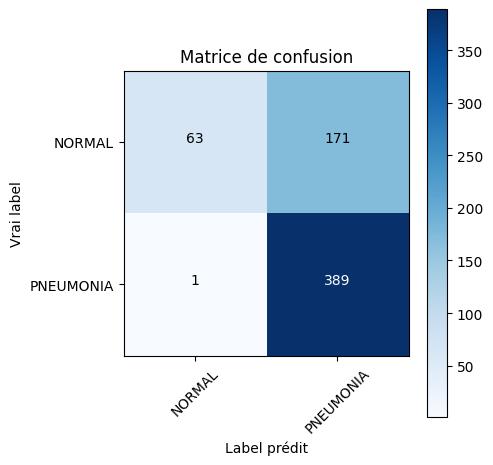

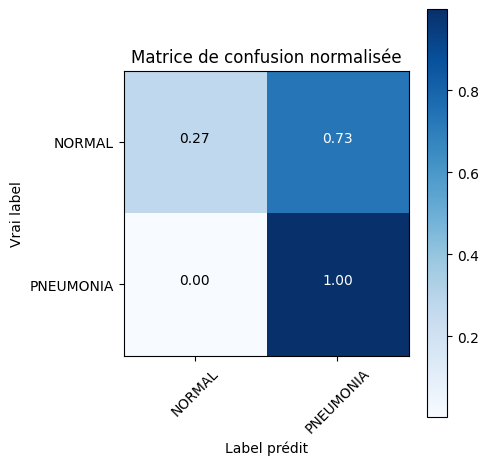

Nombre d'exemples mal classés: 172


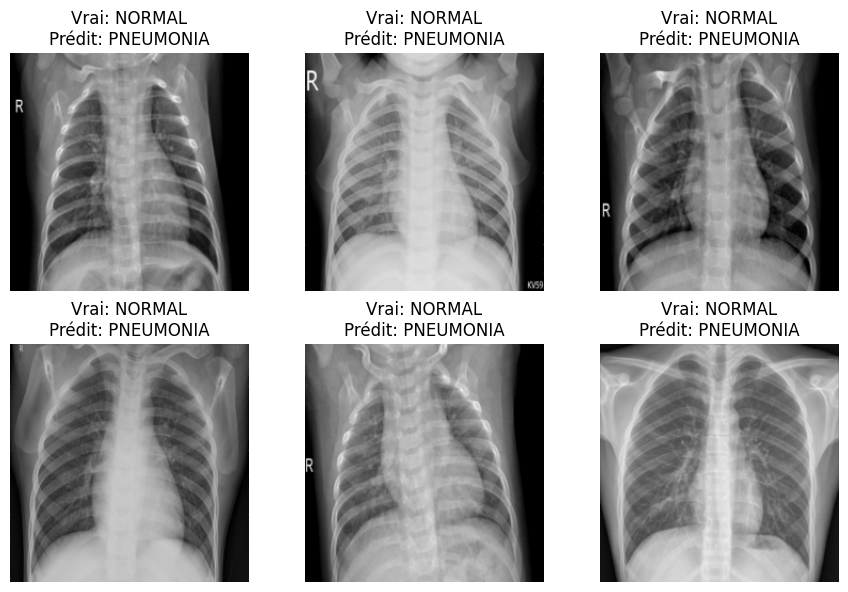

In [26]:
import itertools

def plot_confusion_matrix(cm, classes, normalize=False, title="Matrice de confusion", cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("Vrai label")
    plt.xlabel("Label prédit")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=class_names, normalize=False)
plot_confusion_matrix(cm, classes=class_names, normalize=True, title="Matrice de confusion normalisée")

# Visualisation de quelques erreurs (faux négatifs / faux positifs)
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'exemples mal classés: {len(misclassified_indices)}")

def show_misclassified(test_dataset, y_true, y_pred, indices, n=6):
    if len(indices) == 0:
        print("Aucune erreur à afficher.")
        return
    n = min(n, len(indices))
    chosen = np.random.choice(indices, size=n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * (n // 2), 6))
    axes = axes.flatten()
    for ax, idx in zip(axes, chosen):
        img, label = test_dataset[idx]
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np, cmap="gray")
        ax.set_title(f"Vrai: {class_names[int(y_true[idx])]}\nPrédit: {class_names[int(y_pred[idx])]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_misclassified(test_dataset, y_true, y_pred, misclassified_indices, n=6)


## 10. Interprétabilité avec Grad-CAM

On implémente Grad-CAM pour visualiser les régions de l’image qui contribuent le plus à la prédiction de la classe PNEUMONIA.


/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


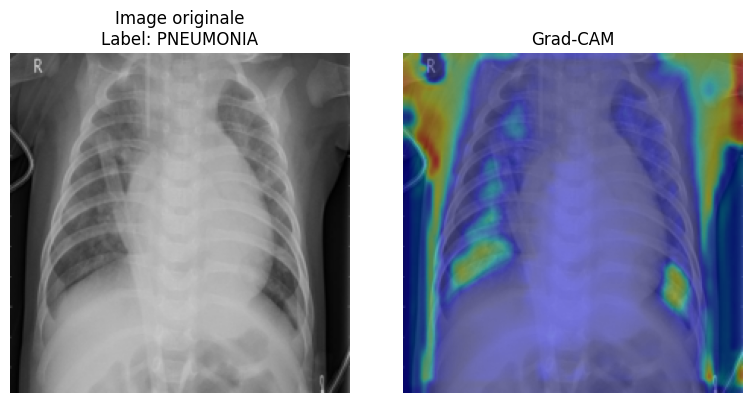

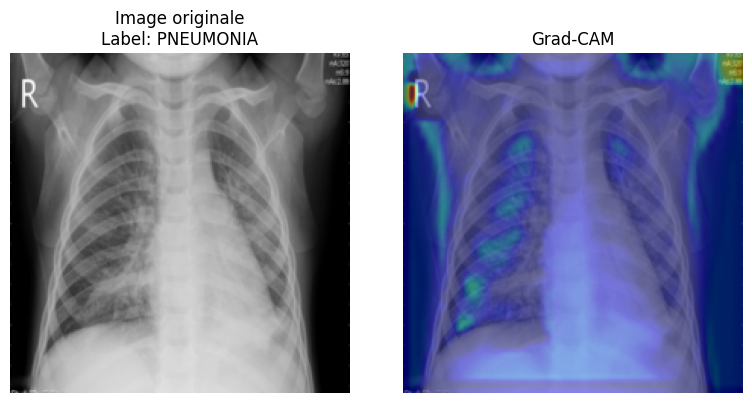

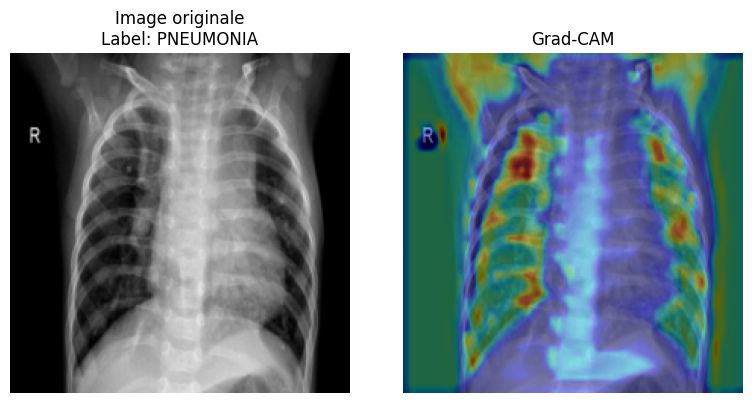

In [27]:
# Grad-CAM (section optionnelle, un peu plus avancée)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.forward_handle = target_layer.register_forward_hook(forward_hook)
        self.backward_handle = target_layer.register_backward_hook(backward_hook)

    def __call__(self, x):
        self.model.eval()
        x = x.to(device)
        self.model.zero_grad()
        logits = self.model(x)  # sortie (logits)
        score = logits.mean()   # score moyen sur le batch
        score.backward()

        gradients = self.gradients      # (N, C, H, W)
        activations = self.activations  # (N, C, H, W)
        weights = gradients.mean(dim=(2, 3), keepdim=True)  # moyenne des gradients
        cam = (weights * activations).sum(dim=1, keepdim=True)  # combinaison linéaire
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

# On cible le dernier bloc convolutionnel
target_layer = model.features[-2]
grad_cam = GradCAM(model, target_layer)

def show_gradcam_on_image(dataset, index, grad_cam):
    img_tensor, label = dataset[index]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    cam = grad_cam(input_tensor)

    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)

    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((img_np.shape[1], img_np.shape[0]))) / 255.0

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np, cmap="gray")
    plt.title(f"Image originale\nLabel: {class_names[label]}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_np, cmap="gray")
    plt.imshow(cam_resized, cmap="jet", alpha=0.4)
    plt.title("Grad-CAM")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Exemple : afficher Grad-CAM sur quelques cas du test set
indices_to_show = np.random.choice(len(test_dataset), size=3, replace=False)
for idx in indices_to_show:
    show_gradcam_on_image(test_dataset, int(idx), grad_cam)


## 11. Sauvegarde du modèle et pistes d’amélioration


In [28]:
torch.save(model.state_dict(), "simple_cnn_pneumonia.pth")
print("Modèle sauvegardé dans simple_cnn_pneumonia.pth")

print("\nPistes d'amélioration possibles :")
print("- Tester le transfert d'apprentissage (ResNet, DenseNet, etc.).")
print("- Ajuster le seuil de décision pour privilégier le Recall (sensibilité) si besoin clinique.")
print("- Gérer explicitement le déséquilibre de classes (class weights, sur-/sous-échantillonnage).")
print("- Affiner les augmentations de données et la régularisation pour limiter l'overfitting.")


Modèle sauvegardé dans simple_cnn_pneumonia.pth

Pistes d'amélioration possibles :
- Tester le transfert d'apprentissage (ResNet, DenseNet, etc.).
- Ajuster le seuil de décision pour privilégier le Recall (sensibilité) si besoin clinique.
- Gérer explicitement le déséquilibre de classes (class weights, sur-/sous-échantillonnage).
- Affiner les augmentations de données et la régularisation pour limiter l'overfitting.
